# Konwolucyjne sieci neuronowe

Głębokie sieci konwolucyjne (CNN) dziłają na zasadzie filtracji stopniowo różnych części danych uczących i wyostrzają
ważne cechy w procesie dyskryminacji z wykorzystywanym do klasyfikacji wzorców. Konwolucje pozwalają ekstrahować proste cechy w początkowych warstwach sieci, a następnie w kolejnych.

Jest
przeznaczona głównie do obliczeń na strukturach 2D, ale sieci konwolucyjne mogą również porządkować
jednostki obliczeniowe w 3D, gdzie wyznacznikami są szerokość, wysokość i głębokość

Naszą prezentacje zaczniemy od importowania bibliotek które będziemy używać:


*   Tensowflow w którym jest Keras do nauczania maszynowego
*   Pandas do wczytywania plików postaci CSV
*   Matplotlib do tworzenia wykresów
*   opendatasets do wczytywania datesetów z strony Kaggle




In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers, utils, regularizers, callbacks
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2024-06-01 05:43:31.697787: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-01 05:43:31.697878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-01 05:43:31.802290: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Wczytajmy dataset z obrazami Motyli:

In [2]:
Dataset = pd.read_csv("/kaggle/input/butterfly-images40-species/butterflies and moths.csv")

Sprawdźmy jak nasz dataset wygląda:

In [3]:
Dataset

,class id,filepaths,labels,data set
0,0,train/ADONIS/001.jpg,ADONIS,train
1,0,train/ADONIS/002.jpg,ADONIS,train
2,0,train/ADONIS/003.jpg,ADONIS,train
3,0,train/ADONIS/004.jpg,ADONIS,train
4,0,train/ADONIS/005.jpg,ADONIS,train
...,...,...,...,...
13589,99,valid/ZEBRA LONG WING/1.jpg,ZEBRA LONG WING,valid
13590,99,valid/ZEBRA LONG WING/2.jpg,ZEBRA LONG WING,valid
13591,99,valid/ZEBRA LONG WING/3.jpg,ZEBRA LONG WING,valid
13592,99,valid/ZEBRA LONG WING/4.jpg,ZEBRA LONG WING,valid


Dodajmy ścieżke do naszego datasetu dla ułatwienia pracy nad nim

In [4]:
Dataset["filepaths"] ="/kaggle/input/butterfly-images40-species/"+ Dataset["filepaths"]
Dataset

,class id,filepaths,labels,data set
0,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
1,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
2,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
3,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
4,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
...,...,...,...,...
13589,99,/kaggle/input/butterfly-images40-species/valid...,ZEBRA LONG WING,valid
13590,99,/kaggle/input/butterfly-images40-species/valid...,ZEBRA LONG WING,valid
13591,99,/kaggle/input/butterfly-images40-species/valid...,ZEBRA LONG WING,valid
13592,99,/kaggle/input/butterfly-images40-species/valid...,ZEBRA LONG WING,valid


Sprawdźmy ile unikalnych klas jest w naszym datasecie i ich poszczególne nazwy

In [5]:
butterfly_classes = Dataset['labels'].unique()
butterfly_classes_num = Dataset['labels'].nunique()
print("Unikalne nazwy poszczególnych klas to:",butterfly_classes, "a ilość unikalnych klas wynosi: ", butterfly_classes_num)

Unikalne nazwy poszczególnych klas to: ['ADONIS' 'AFRICAN GIANT SWALLOWTAIL' 'AMERICAN SNOOT' 'AN 88' 'APPOLLO'
 'ARCIGERA FLOWER MOTH' 'ATALA' 'ATLAS MOTH' 'BANDED ORANGE HELICONIAN'
 'BANDED PEACOCK' 'BANDED TIGER MOTH' 'BECKERS WHITE'
 'BIRD CHERRY ERMINE MOTH' 'BLACK HAIRSTREAK' 'BLUE MORPHO'
 'BLUE SPOTTED CROW' 'BROOKES BIRDWING' 'BROWN ARGUS' 'BROWN SIPROETA'
 'CABBAGE WHITE' 'CAIRNS BIRDWING' 'CHALK HILL BLUE' 'CHECQUERED SKIPPER'
 'CHESTNUT' 'CINNABAR MOTH' 'CLEARWING MOTH' 'CLEOPATRA'
 'CLODIUS PARNASSIAN' 'CLOUDED SULPHUR' 'COMET MOTH' 'COMMON BANDED AWL'
 'COMMON WOOD-NYMPH' 'COPPER TAIL' 'CRECENT' 'CRIMSON PATCH'
 'DANAID EGGFLY' 'EASTERN COMA' 'EASTERN DAPPLE WHITE'
 'EASTERN PINE ELFIN' 'ELBOWED PIERROT' 'EMPEROR GUM MOTH'
 'GARDEN TIGER MOTH' 'GIANT LEOPARD MOTH' 'GLITTERING SAPPHIRE'
 'GOLD BANDED' 'GREAT EGGFLY' 'GREAT JAY' 'GREEN CELLED CATTLEHEART'
 'GREEN HAIRSTREAK' 'GREY HAIRSTREAK' 'HERCULES MOTH'
 'HUMMING BIRD HAWK MOTH' 'INDRA SWALLOW' 'IO MOTH' 'Iphiclus sis

# Preprocessing
Stwórzmy funkcja która będzie augmentować nasz dataset, a następnie wyciągnie nasze zdjęcia z folderu korzystając z pliku CSV.
Augmentacja będzie polegała na:

1.  Przeskalowaniu poszczególnych pikseli dla ułatwienia w nauczaniu maszynowym
2.  rotacji do 40 stopni
3.  przeskalowaniu w szerokości i wysokości
4.  przytnięciu
5.  odbiciu w poziomie





In [6]:
def prep_data(train_data, validation_data, test_data, batch_size=32, augment = True):
    IMAGE_SIZE = (224,224)
    if augment:
        train_datagen = ImageDataGenerator(
              rescale=1./255,
              rotation_range=40,
              width_shift_range=0.2,
              height_shift_range=0.2,
              shear_range=0.2,
              zoom_range=0.2,
              horizontal_flip=True)

        validation_datagen = ImageDataGenerator(rescale=1./255)
    else:
        train_datagen = ImageDataGenerator(rescale=1./255)
        validation_datagen = ImageDataGenerator(rescale=1./255)
    
    train_set = train_datagen.flow_from_dataframe(
        dataframe=train_data,
        x_col='filepaths',
        y_col='labels',
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        seed = 10,
        class_mode='sparse')

    validation_set = validation_datagen.flow_from_dataframe(
        dataframe=validation_data,
        x_col='filepaths',
        y_col='labels',
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        seed = 10,
        class_mode='sparse')
    
    test_set = validation_datagen.flow_from_dataframe(
        dataframe=test_data,
        x_col='filepaths',
        y_col='labels',
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        seed = 10,
        class_mode='sparse')

    return train_set, validation_set, test_set

A tu jest funkcja która będzie tworzyła wykres po wyuczeniu modelu

In [7]:
def plotuj(model):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(model.history['accuracy'], label='accuracy')
    ax[0].plot(model.history['val_accuracy'], label = 'val_accuracy')
    ax[0].set_title("Treningowy i walidacyjny zbior - dokladnosc")
    ax[1].plot(model.history['loss'], label='loss')
    ax[1].plot(model.history['val_loss'], label = 'val_loss')
    ax[1].set_title("Treningowy i walidacyjny zbior - funkcja straty")
    ax[0].legend(loc='lower right')
    ax[1].legend(loc='lower right')
    ax[0].set_xlabel("epokq")
    ax[1].set_xlabel("epoka")
    plt.tight_layout()
    plt.show()

Ustalmy nasz set treningowy, walidacyjny i testowy

In [8]:
train_data = Dataset.loc[Dataset["data set"] == "train"]
validation_data = Dataset.loc[Dataset["data set"] == "valid"]
test_data = Dataset.loc[Dataset["data set"] == "test"]
print("Rozmiar setu treningowego: ",len(train_data)," walidacyjnego: ",len(validation_data),"testowego: ",len(test_data))

Rozmiar setu treningowego:  12594  walidacyjnego:  500 testowego:  500


Sprawdzmy jak wyglądają nasze obrazki, bez augmentowania:

In [9]:
train_set, validation_set, test_set = prep_data(train_data, validation_data, test_data,  augment = False)

Found 12594 validated image filenames belonging to 100 classes.
Found 500 validated image filenames belonging to 100 classes.
Found 500 validated image filenames belonging to 100 classes.


# Podgląd w dane
Jak widzimy mamy 12594 obrazków w treningowym zbiorze i 500 obrazków w Walidacyjnym zbiorze

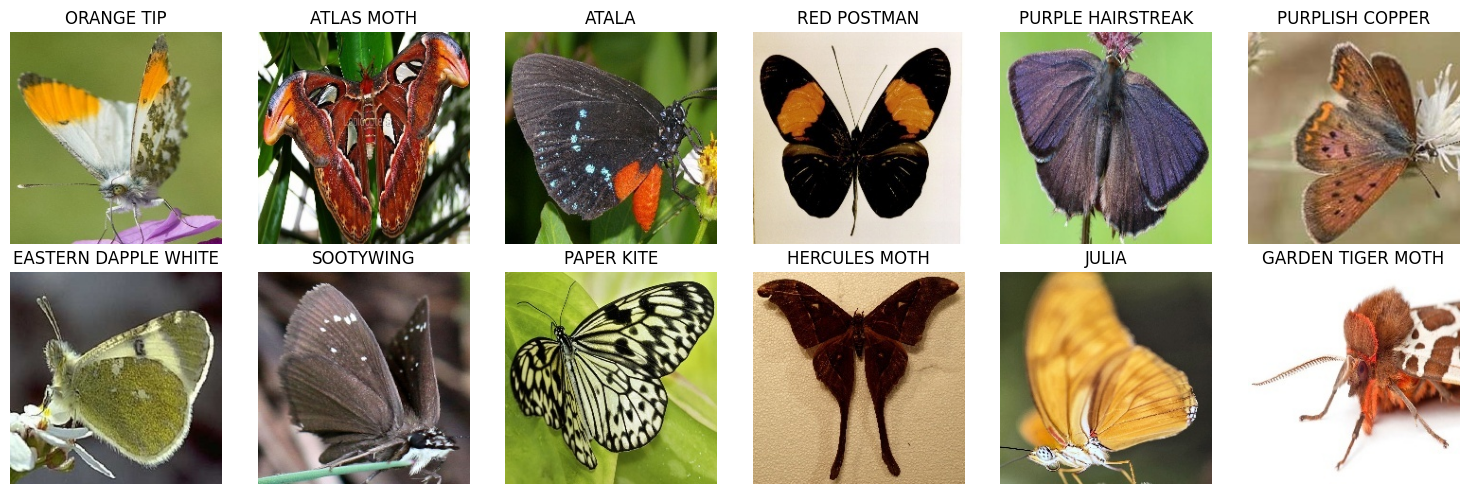

In [10]:
image, label = next(train_set)

class_names = train_set.class_indices
class_names = {v: k for k, v in class_names.items()}

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(12):
    axes[i//6][i%6].imshow(image[i])
    label_index = int(label[i])
    class_name = class_names[label_index]
    axes[i//6][i%6].set_title(f"{class_name}")
    axes[i//6][i%6].axis('off')

plt.tight_layout()
plt.show()

A teraz go augmentujmy

In [11]:
train_set, validation_set, test_set = prep_data(train_data, validation_data, test_data)

Found 12594 validated image filenames belonging to 100 classes.
Found 500 validated image filenames belonging to 100 classes.
Found 500 validated image filenames belonging to 100 classes.


Spójrzmy na obrazy jeszcze raz, już po augmentacji:

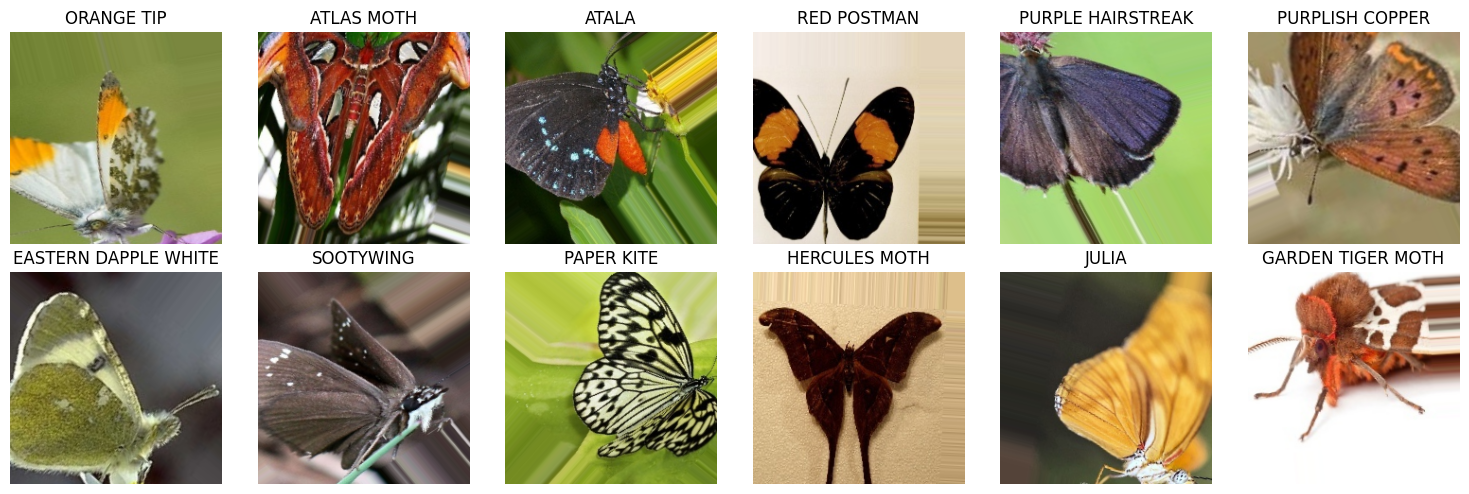

In [12]:
image, label = next(train_set)
class_names = train_set.class_indices
class_names = {v: k for k, v in class_names.items()}
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(12):
    axes[i//6][i%6].imshow(image[i])
    label_index = int(label[i])
    class_name = class_names[label_index]
    axes[i//6][i%6].set_title(f"{class_name}")
    axes[i//6][i%6].axis('off')

plt.tight_layout()
plt.show()

# Pierwszy model
Nieźle, jak widzimy nasz zestaw treningowy jest augmentowany.
Stwórzmy pierwszy model dla naszego nauczania maszynowego

In [13]:
model = models.Sequential()
model.add(layers.Conv2D(filters=32,kernel_size=(3,3), activation='relu', input_shape = (224,224,3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(100 , activation='softmax'))

model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 880,868 (3.36 MB)

 Trainable params: 880,868 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

Teraz uruchomimy nasz model:

In [14]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(0.0005), 
    metrics=['accuracy']
)
model1_1 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback]
    )

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  2/394 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.0234 - loss: 4.6105   

I0000 00:00:1717220694.389142      76 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1717220694.409066      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


378/394 ━━━━━━━━━━━━━━━━━━━━ 9s 584ms/step - accuracy: 0.0157 - loss: 4.5554 

...

394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.0160 - loss: 4.5513

W0000 00:00:1717220921.241714      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 249s 591ms/step - accuracy: 0.0160 - loss: 4.5510 - val_accuracy: 0.0460 - val_loss: 4.1593
Epoch 2/50


W0000 00:00:1717220926.524687      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 166s 414ms/step - accuracy: 0.0562 - loss: 4.0545 - val_accuracy: 0.1260 - val_loss: 3.4527
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 166s 414ms/step - accuracy: 0.1200 - loss: 3.5448 - val_accuracy: 0.3040 - val_loss: 2.6812
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 416ms/step - accuracy: 0.2228 - loss: 3.0866 - val_accuracy: 0.3680 - val_loss: 2.3297
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 416ms/step - accuracy: 0.3020 - loss: 2.6475 - val_accuracy: 0.4540 - val_loss: 2.0891
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 415ms/step - accuracy: 0.3738 - loss: 2.3554 - val_accuracy: 0.5520 - val_loss: 1.5673
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 165s 411ms/step - accuracy: 0.4232 - loss: 2.0983 - val_accuracy: 0.6080 - val_loss: 1.4106
Epoch 8/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 166s 414ms/step - accuracy: 0.4835 - loss: 1.9041 - val_accuracy: 0.6920 - val_loss: 1.1188
Epoch 9/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 166s 413ms/step - accuracy: 0.5275 - loss: 1.70

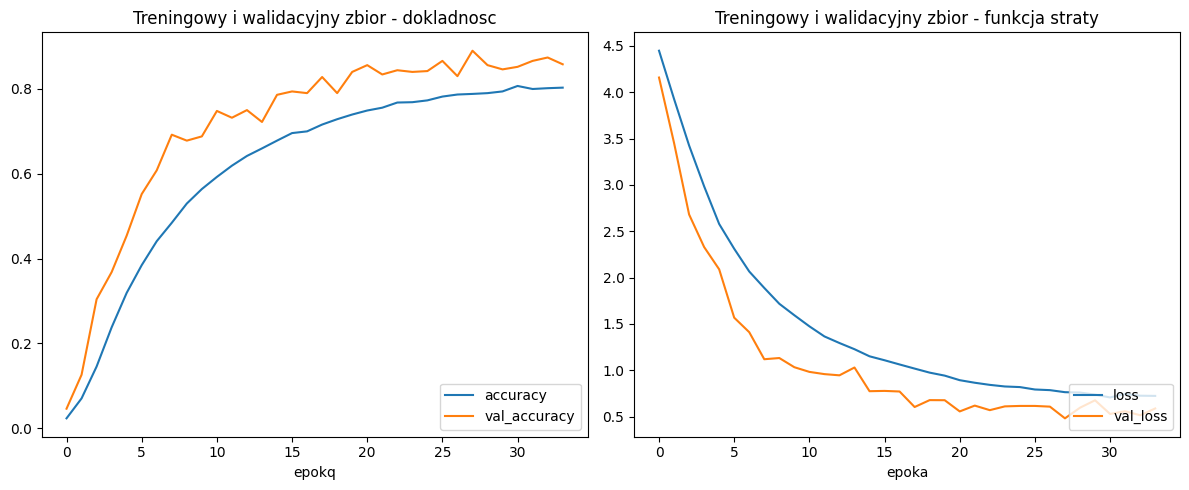

In [15]:
plotuj(model1_1)

In [16]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 347ms/step - accuracy: 0.8867 - loss: 0.4876


[0.39642536640167236, 0.8960000276565552]

# Drugi model
Stwórzmy nowy model, bardziej rozbudowany

In [17]:
model = models.Sequential()
model.add(layers.Conv2D(filters=32,kernel_size=(3,3), activation='relu', input_shape = (224,224,3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(516, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(100, activation='softmax'))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 107, 107, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 516)            │       132,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 516)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        51,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,901,176 (30.14 MB)

 Trainable params: 7,901,176 (30.14 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [19]:
model1_2 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback])

Epoch 1/50
  1/394 ━━━━━━━━━━━━━━━━━━━━ 2:10:10 20s/step - accuracy: 0.0000e+00 - loss: 4.6063

W0000 00:00:1717226548.860431      77 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


136/394 ━━━━━━━━━━━━━━━━━━━━ 2:09 503ms/step - accuracy: 0.0103 - loss: 4.6055

W0000 00:00:1717226616.662607      77 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.0141 - loss: 4.5530

W0000 00:00:1717226733.933419      77 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 210s 484ms/step - accuracy: 0.0141 - loss: 4.5528 - val_accuracy: 0.0320 - val_loss: 4.2638
Epoch 2/50


W0000 00:00:1717226739.272384      75 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 230s 441ms/step - accuracy: 0.0372 - loss: 4.1854 - val_accuracy: 0.1340 - val_loss: 3.5718
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 169s 420ms/step - accuracy: 0.0877 - loss: 3.8039 - val_accuracy: 0.1620 - val_loss: 3.2989
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 417ms/step - accuracy: 0.1487 - loss: 3.4302 - val_accuracy: 0.3320 - val_loss: 2.6457
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 417ms/step - accuracy: 0.2451 - loss: 2.9772 - val_accuracy: 0.3940 - val_loss: 2.2692
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 202s 416ms/step - accuracy: 0.3029 - loss: 2.6328 - val_accuracy: 0.5520 - val_loss: 1.7163
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 417ms/step - accuracy: 0.3773 - loss: 2.3743 - val_accuracy: 0.5840 - val_loss: 1.5021
Epoch 8/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 170s 423ms/step - accuracy: 0.4425 - loss: 2.0749 - val_accuracy: 0.6280 - val_loss: 1.4157
Epoch 9/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 168s 417ms/step - accuracy: 0.5033 - loss: 1.86

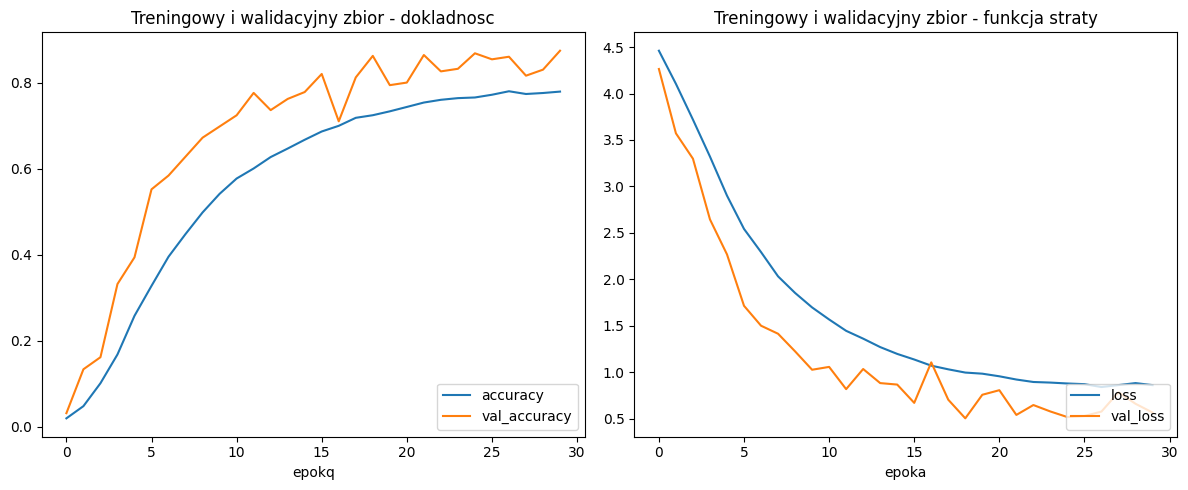

In [20]:
plotuj(model1_2)

In [21]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9260 - loss: 0.3387


[0.3767547011375427, 0.9179999828338623]

# Trzeci Model

In [22]:
model = models.Sequential()

model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.25))

model.add(layers.Dense(100, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 107, 107, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 107, 107, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 123904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │    15,859,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,447,332 (62.74 MB)

 Trainable params: 16,446,500 (62.74 MB)

 Non-trainable params: 832 (3.25 KB)

In [23]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [24]:
model1_3 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback])

Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 186s 439ms/step - accuracy: 0.0221 - loss: 5.9775 - val_accuracy: 0.0320 - val_loss: 6.2992
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 415ms/step - accuracy: 0.1009 - loss: 3.9383 - val_accuracy: 0.2280 - val_loss: 3.1556
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 169s 421ms/step - accuracy: 0.1845 - loss: 3.3271 - val_accuracy: 0.3040 - val_loss: 3.9379
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 416ms/step - accuracy: 0.2587 - loss: 2.9368 - val_accuracy: 0.4500 - val_loss: 2.2112
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 169s 421ms/step - accuracy: 0.3294 - loss: 2.6297 - val_accuracy: 0.4680 - val_loss: 2.0661
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 168s 418ms/step - accuracy: 0.3792 - loss: 2.3938 - val_accuracy: 0.5540 - val_loss: 1.7654
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 415ms/step - accuracy: 0.4164 - loss: 2.2181 - val_accuracy: 0.6060 - val_loss: 1.6027
Epoch 8/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 417ms/step - accuracy: 0.4621 -

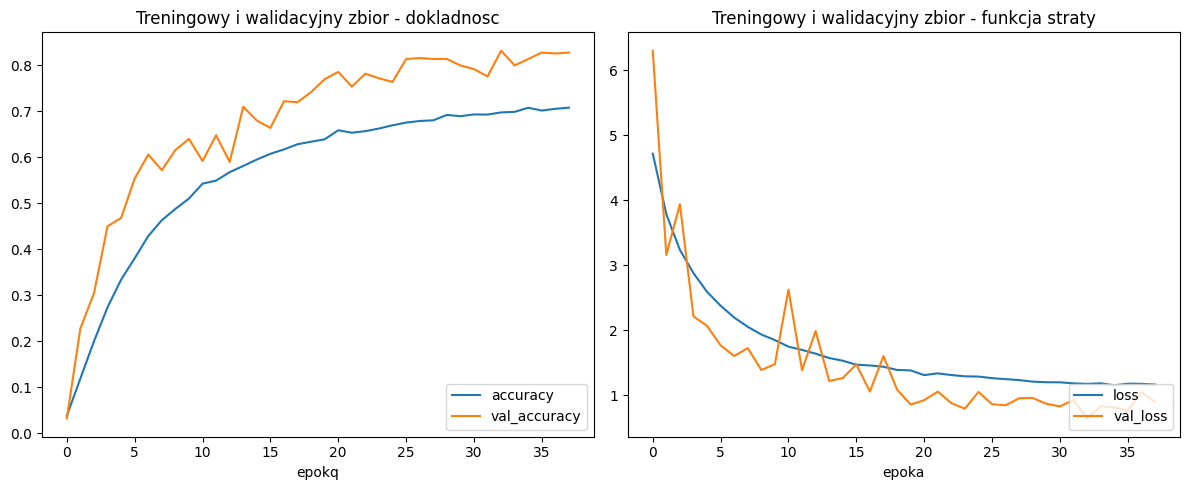

In [25]:
plotuj(model1_3)

In [26]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8303 - loss: 0.7583


[0.7875104546546936, 0.8220000267028809]

# Czwarty model

In [27]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(100 , activation='softmax'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 107, 107, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 51, 51, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 49, 49, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 22, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,340,580 (5.11 MB)

 Trainable params: 1,340,580 (5.11 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

model1_4 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback])

Epoch 1/50
  2/394 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.0000e+00 - loss: 4.6055  

W0000 00:00:1717238241.898577      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


126/394 ━━━━━━━━━━━━━━━━━━━━ 2:03 463ms/step - accuracy: 0.0065 - loss: 4.6115

W0000 00:00:1717238299.659016      77 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.0095 - loss: 4.6067

W0000 00:00:1717238410.168830      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 183s 435ms/step - accuracy: 0.0095 - loss: 4.6066 - val_accuracy: 0.0260 - val_loss: 4.3552
Epoch 2/50


W0000 00:00:1717238412.934577      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 415ms/step - accuracy: 0.0258 - loss: 4.3330 - val_accuracy: 0.0800 - val_loss: 3.8493
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 170s 424ms/step - accuracy: 0.0644 - loss: 3.9481 - val_accuracy: 0.1260 - val_loss: 3.4615
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 200s 419ms/step - accuracy: 0.1273 - loss: 3.5448 - val_accuracy: 0.2520 - val_loss: 3.0634
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 166s 415ms/step - accuracy: 0.1833 - loss: 3.2241 - val_accuracy: 0.2960 - val_loss: 2.7412
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 169s 421ms/step - accuracy: 0.2669 - loss: 2.8460 - val_accuracy: 0.4240 - val_loss: 2.1608
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 168s 418ms/step - accuracy: 0.3238 - loss: 2.5254 - val_accuracy: 0.4480 - val_loss: 1.9953
Epoch 8/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 169s 422ms/step - accuracy: 0.3914 - loss: 2.2757 - val_accuracy: 0.5560 - val_loss: 1.6369
Epoch 9/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 168s 418ms/step - accuracy: 0.4411 - loss: 2.04

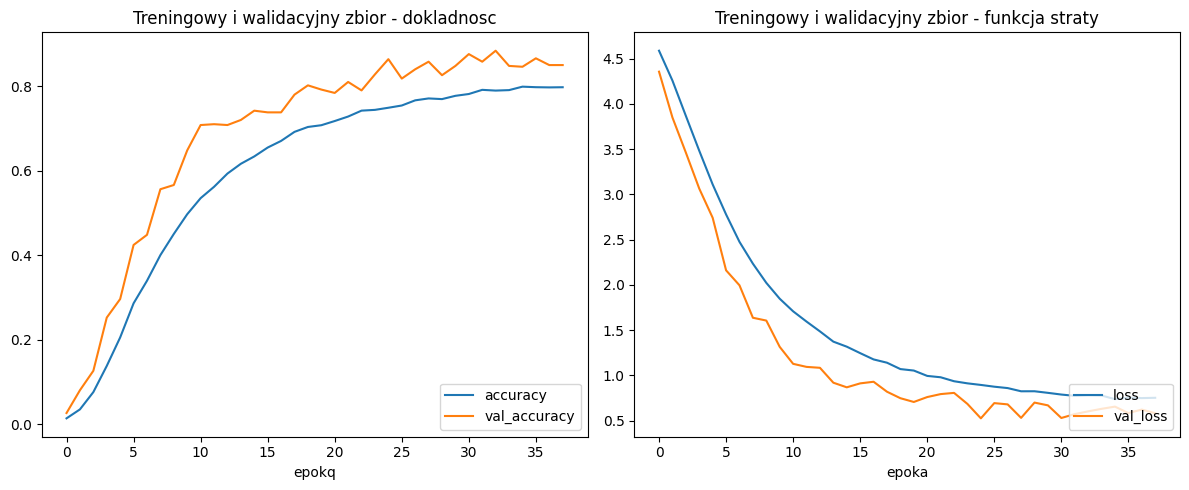

In [29]:
plotuj(model1_4)

In [30]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8663 - loss: 0.5119


[0.4646276831626892, 0.8820000290870667]

# Piaty model

In [31]:
model = models.Sequential()
    
model.add(layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.BatchNormalization(axis=-1))

model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.BatchNormalization(axis=-1))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(100, activation='softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 220, 220, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 110, 110, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 106, 106, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 53, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 53, 53, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 359552)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │   184,091,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,242,564 (702.83 MB)

 Trainable params: 184,241,220 (702.82 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [32]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
model1_5 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback])

Epoch 1/50
  1/394 ━━━━━━━━━━━━━━━━━━━━ 2:58:07 27s/step - accuracy: 0.0000e+00 - loss: 6.2353

W0000 00:00:1717244826.287287      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


 52/394 ━━━━━━━━━━━━━━━━━━━━ 4:01 707ms/step - accuracy: 0.0275 - loss: 5.7305

W0000 00:00:1717244862.385159      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.0922 - loss: 4.6650

W0000 00:00:1717245007.957641      75 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 215s 477ms/step - accuracy: 0.0923 - loss: 4.6633 - val_accuracy: 0.0660 - val_loss: 4.3841
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 169s 420ms/step - accuracy: 0.2813 - loss: 2.9609 - val_accuracy: 0.4380 - val_loss: 2.2528
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 172s 427ms/step - accuracy: 0.3986 - loss: 2.3984 - val_accuracy: 0.5460 - val_loss: 1.7087
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 170s 424ms/step - accuracy: 0.4801 - loss: 2.0341 - val_accuracy: 0.6620 - val_loss: 1.3015
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 170s 424ms/step - accuracy: 0.5319 - loss: 1.8349 - val_accuracy: 0.7020 - val_loss: 1.2213
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 170s 424ms/step - accuracy: 0.5687 - loss: 1.6815 - val_accuracy: 0.7180 - val_loss: 1.0883
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 169s 422ms/step - accuracy: 0.5924 - loss: 1.5392 - val_accuracy: 0.6220 - val_loss: 1.4442
Epoch 8/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 170s 423ms/step - accuracy: 0.6440 - loss: 1.38

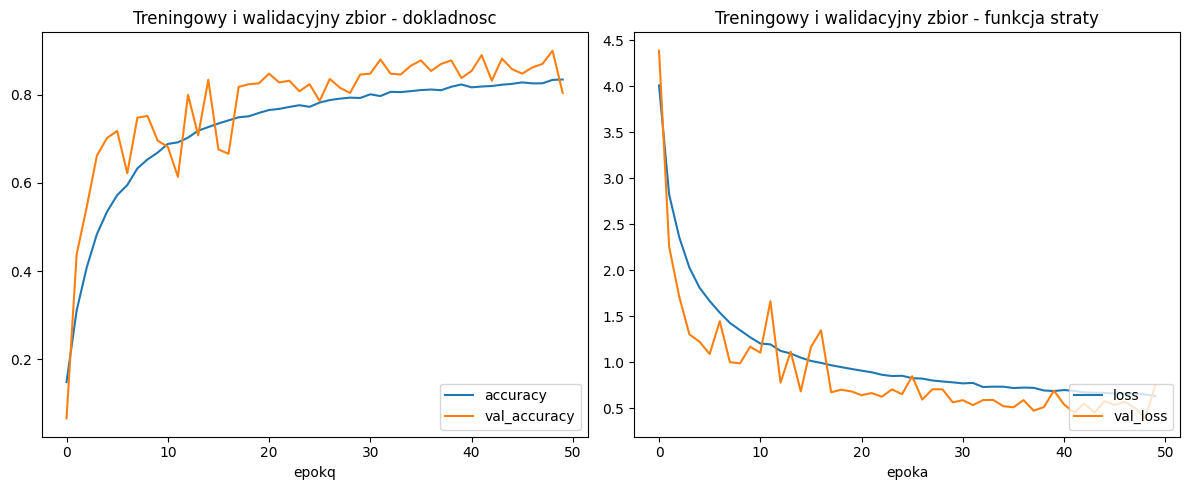

In [33]:
plotuj(model1_5)

In [34]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.8108 - loss: 0.8865


[0.7100055813789368, 0.8220000267028809]

# Inception V3

Teraz użyjemy dostępny w Kerasie, gotowy model do nauczania konwolucyjnego, zwany InceptionV3. 

Na obrazie poniżej, jest wgląd w jego budowę
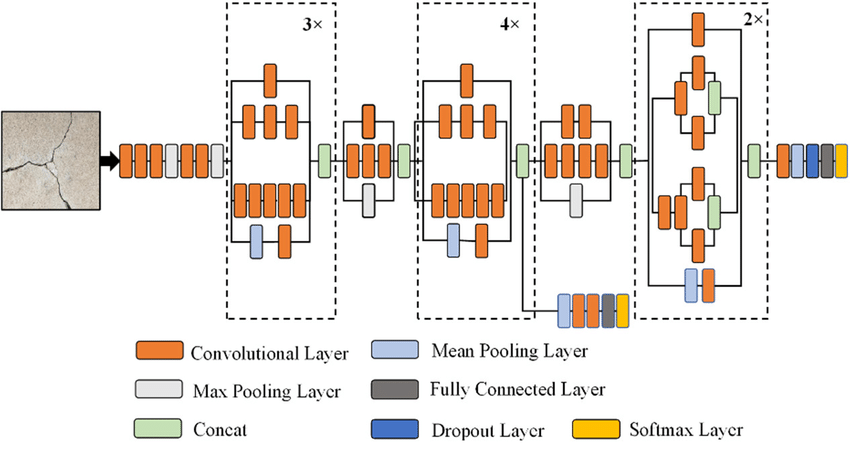

Zacznijmy od importowania tego modelu

In [35]:
from tensorflow.keras.applications import InceptionV3
base_model = InceptionV3(
    include_top=False,
    input_shape=(224, 224, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Ponieważ InceptionV3 odpowiada tylko za część konwolucyjną, to osobno musimy dodać warstwę pełnie połączoną

In [36]:
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(100, activation='softmax'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ ?                      │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [37]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate = 0.0005), 
    metrics=['accuracy']
)

In [38]:
fine_tune_inception1_1 = model.fit(
    train_set,
    epochs=30,
    validation_data=validation_set,
    callbacks = [callback]
    )

Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 321s 604ms/step - accuracy: 0.1631 - loss: 4.1011 - val_accuracy: 0.5640 - val_loss: 2.6978
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 175s 436ms/step - accuracy: 0.7045 - loss: 1.1153 - val_accuracy: 0.7080 - val_loss: 1.4116
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 174s 433ms/step - accuracy: 0.7811 - loss: 0.8031 - val_accuracy: 0.5040 - val_loss: 4.7909
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 174s 433ms/step - accuracy: 0.8146 - loss: 0.6821 - val_accuracy: 0.8320 - val_loss: 0.9818
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 200s 429ms/step - accuracy: 0.8407 - loss: 0.5714 - val_accuracy: 0.8700 - val_loss: 0.6132
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 174s 432ms/step - accuracy: 0.8596 - loss: 0.5204 - val_accuracy: 0.8320 - val_loss: 0.9983
Epoch 7/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 177s 442ms/step - accuracy: 0.8729 - loss: 0.4626 - val_accuracy: 0.8620 - val_loss: 1.0641
Epoch 8/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 178s 442ms/step - accuracy: 0.8840 -

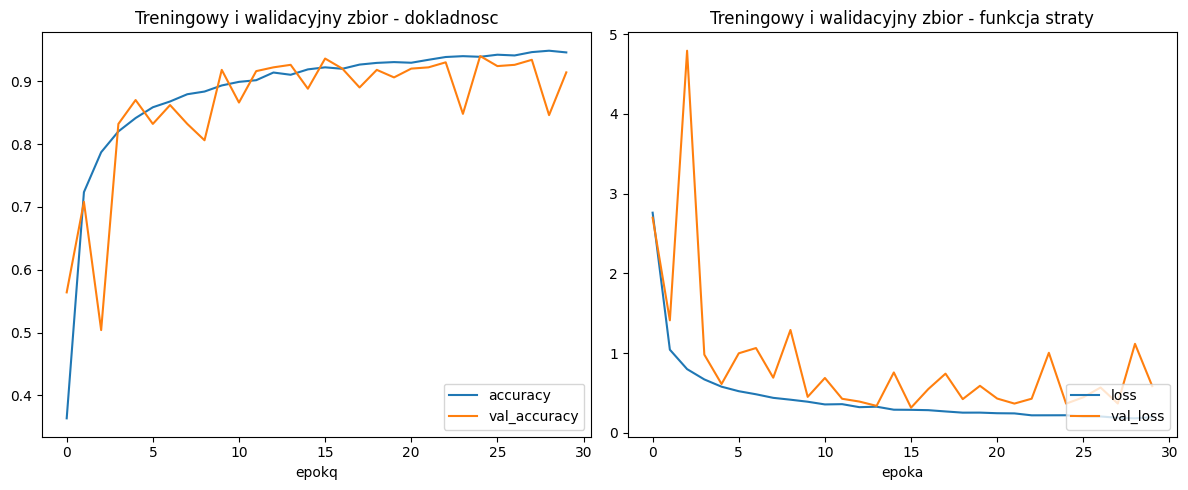

In [39]:
plotuj(fine_tune_inception1_1)

In [40]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9179 - loss: 0.5043


[0.5551067590713501, 0.9179999828338623]

Zauważmy, że dokładność w tym modelu jest bardzo wysoka. Zobaczmy kilka przykładów jak radzi on sobie na zbiorze testowym

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Gatunek prawdziwy:  CLOUDED SULPHUR
Gatunek przewidywany:  CLOUDED SULPHUR


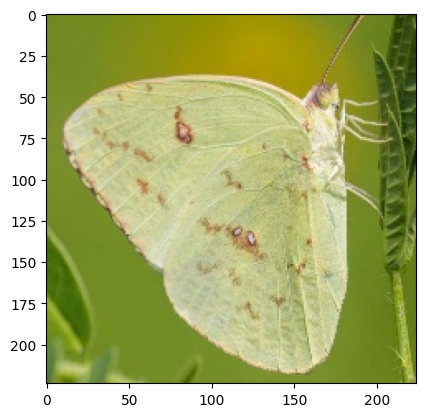

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Gatunek prawdziwy:  PAPER KITE
Gatunek przewidywany:  PAPER KITE


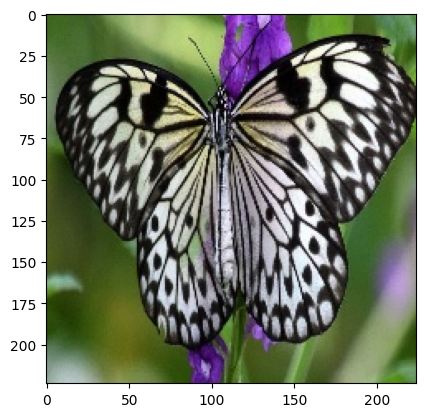

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Gatunek prawdziwy:  BIRD CHERRY ERMINE MOTH
Gatunek przewidywany:  BIRD CHERRY ERMINE MOTH


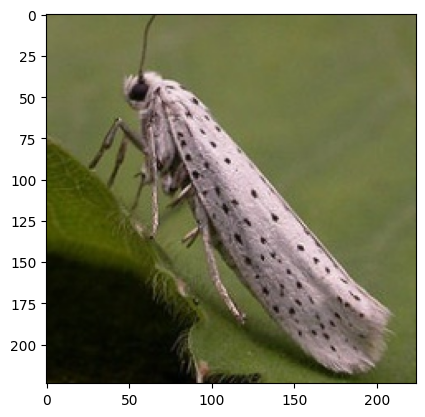

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Gatunek prawdziwy:  MALACHITE
Gatunek przewidywany:  MALACHITE


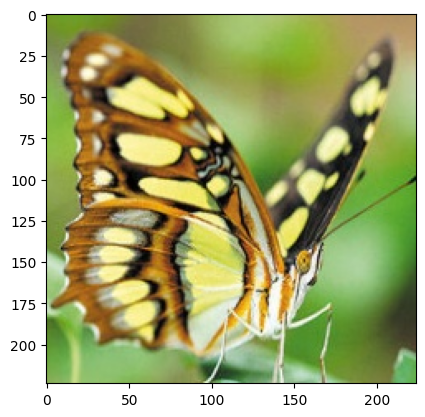

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Gatunek prawdziwy:  INDRA SWALLOW
Gatunek przewidywany:  INDRA SWALLOW


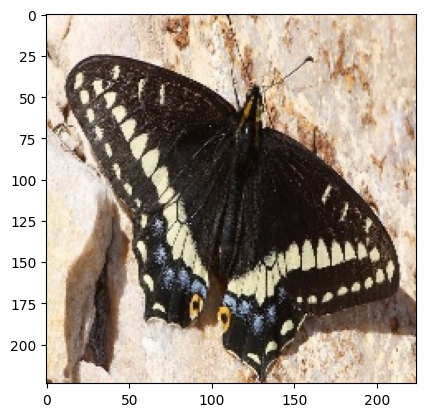

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Gatunek prawdziwy:  RED SPOTTED PURPLE
Gatunek przewidywany:  RED SPOTTED PURPLE


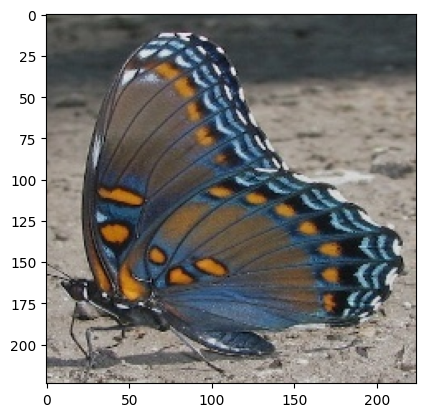

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Gatunek prawdziwy:  PURPLISH COPPER
Gatunek przewidywany:  PURPLISH COPPER


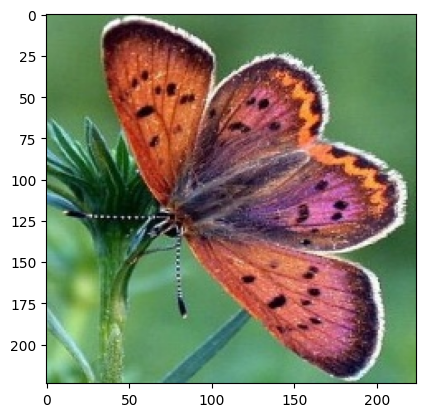

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Gatunek prawdziwy:  MESTRA
Gatunek przewidywany:  MESTRA


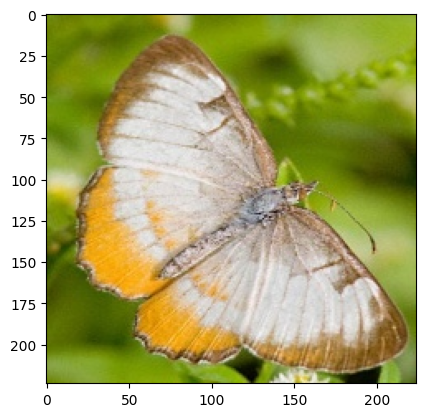

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Gatunek prawdziwy:  COPPER TAIL
Gatunek przewidywany:  CRECENT


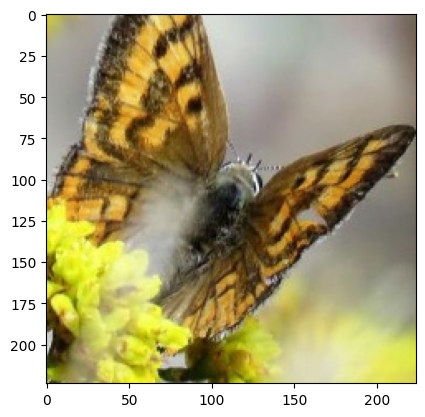

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Gatunek prawdziwy:  DANAID EGGFLY
Gatunek przewidywany:  GREAT EGGFLY


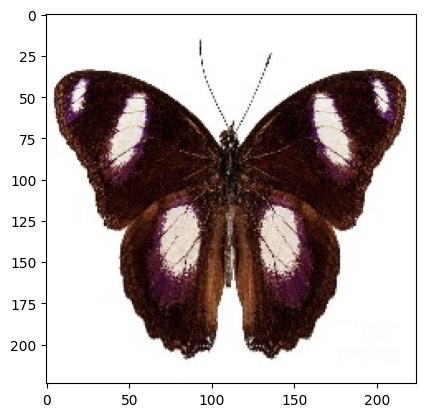

In [41]:
image, temp = next(test_set)
for i in range(10):
    prediction = model.predict(image)
    print("Gatunek prawdziwy: ", class_names[int(temp[i])])
    print("Gatunek przewidywany: ", class_names [prediction[i].argmax()])
    plt.imshow(image[i])
    plt.show()

In [42]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9066 - loss: 0.7137


[0.550706148147583, 0.9179999828338623]

# Inception V3 rozbudowany
Kolejny model 

In [43]:
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(75, activation='softmax'))
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [44]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005), 
    metrics=['accuracy']
)
fine_tune_inception1_2 = model.fit(
    train_set,
    epochs=30,
    validation_data=validation_set,
    callbacks = [callback]
    )

Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 281s 562ms/step - accuracy: 0.0121 - loss: nan - val_accuracy: 0.0100 - val_loss: nan
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 176s 439ms/step - accuracy: 0.0104 - loss: nan - val_accuracy: 0.0100 - val_loss: nan
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 177s 440ms/step - accuracy: 0.0129 - loss: nan - val_accuracy: 0.0100 - val_loss: nan


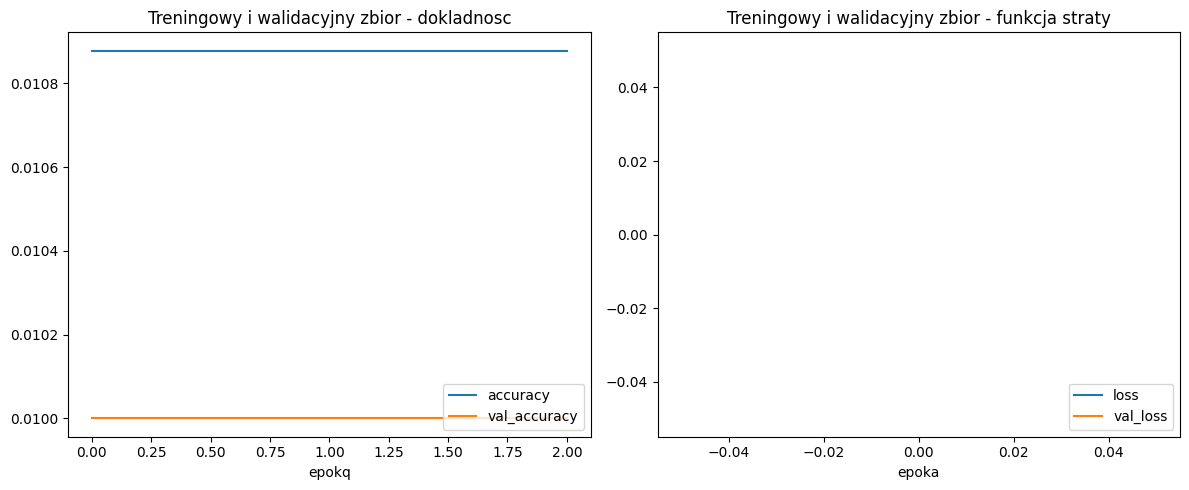

In [45]:
plotuj(fine_tune_inception1_2)

In [46]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.0081 - loss: nan


[nan, 0.009999999776482582]

# InceptionV3 zbudowana wersja

Spróbujmy stworzyć nasz własny InceptionV3 używając dokumentacji 

In [47]:
from keras.models import Model
from keras.layers import concatenate
from keras.layers import Conv2D , MaxPooling2D , Input , GlobalAveragePooling2D ,AveragePooling2D, Dense , Dropout ,Activation, Flatten , BatchNormalization


def Conv2D_z_Batch_Normalisation(prev_layer , filters , kernel_size , strides =(1,1) , padding = 'same'):
    x = Conv2D(filters=filters, kernel_size = kernel_size, strides=strides , padding=padding, use_bias = False)(prev_layer)
    x = BatchNormalization(axis=3, scale = False)(x)
    x = Activation(activation='relu')(x)
    return x

def StemBlock(prev_layer):
    x = Conv2D_z_Batch_Normalisation(prev_layer,filters= 32, kernel_size = (3,3) , strides=(2,2), padding = 'valid')
    x = Conv2D_z_Batch_Normalisation(x, 32, (3,3), padding="valid")
    x = Conv2D_z_Batch_Normalisation(x, 64, kernel_size=(3,3))
    x = MaxPooling2D(pool_size=(3,3) , strides=(2,2)) (x)
    
    x = Conv2D_z_Batch_Normalisation(x, 80, (1,1), padding="valid")
    x = Conv2D_z_Batch_Normalisation(x, 192, (3,3), padding="valid")
    x = MaxPooling2D(pool_size=(3,3) , strides=(2,2)) (x)
    
    return x    
    

def InceptionBlock_A(prev_layer  , filters):
    
    branch1x1 = Conv2D_z_Batch_Normalisation(prev_layer, filters = 64, kernel_size=(1,1))

    branch5x5 = Conv2D_z_Batch_Normalisation(prev_layer, 48, (1,1))
    branch5x5 = Conv2D_z_Batch_Normalisation(branch5x5, 64, (5,5)) 
       
    branch3x3 = Conv2D_z_Batch_Normalisation(prev_layer, 64, (1,1))
    branch3x3 = Conv2D_z_Batch_Normalisation(branch3x3, 96, (3,3))
    branch3x3 = Conv2D_z_Batch_Normalisation(branch3x3, 96, (3,3))
    
    branch_pool = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding='same') (prev_layer)
    branch_pool = Conv2D_z_Batch_Normalisation(branch_pool, filters, (1,1))
    
    
    output = concatenate([branch1x1 , branch5x5 , branch3x3 , branch_pool], axis=3)
    
    return output



def InceptionBlock_B(prev_layer , filters):
    
    branch1x1= Conv2D_z_Batch_Normalisation(prev_layer, filters = 192, kernel_size = (1,1))

    branch7x7 = Conv2D_z_Batch_Normalisation(prev_layer, filters = filters, kernel_size = (1,1))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, filters = filters, kernel_size = (1,7))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, 192, (7,1))
    
    
    branch7x7_ = Conv2D_z_Batch_Normalisation(prev_layer, filters = filters, kernel_size = (1,1))
    branch7x7_ = Conv2D_z_Batch_Normalisation(branch7x7_, filters = filters, kernel_size = (7,1))
    branch7x7_ = Conv2D_z_Batch_Normalisation(branch7x7_, filters = filters, kernel_size = (1,7))
    branch7x7_ = Conv2D_z_Batch_Normalisation(branch7x7_, filters = filters, kernel_size = (7,1))    
    branch7x7_ = Conv2D_z_Batch_Normalisation(branch7x7_, 192, (1,7))
    
    branch_pool = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding ='same') (prev_layer)
    branch_pool = Conv2D_z_Batch_Normalisation(branch_pool, 192, (1,1))
    
    
    output = concatenate([branch1x1 , branch7x7 , branch7x7_ , branch_pool], axis = 3)
    
    return output    


    
def InceptionBlock_C(prev_layer):
    
    branch1x1 = Conv2D_z_Batch_Normalisation(prev_layer, filters = 320, kernel_size = (1,1))

    branch3x3 = Conv2D_z_Batch_Normalisation(prev_layer, 384, (1,1))
    branch3x3_1 = Conv2D_z_Batch_Normalisation(branch3x3, 384, (1,3))
    branch3x3_2 = Conv2D_z_Batch_Normalisation(branch3x3, 384, (3,1))
    branch3x3 = concatenate([branch3x3_1 , branch3x3_2], axis = 3)
    
    branch3x3_ = Conv2D_z_Batch_Normalisation(prev_layer, 448, (1,1))
    branch3x3_ = Conv2D_z_Batch_Normalisation(branch3x3_, 384, (3,3))
    branch3x3_1_ = Conv2D_z_Batch_Normalisation(branch3x3_, 384, (1,3))    
    branch3x3_2_ = Conv2D_z_Batch_Normalisation(branch3x3_, 384, (3,1))
    branch3x3_ = concatenate([branch3x3_1_ , branch3x3_2_], axis = 3)
    
    branch_pool = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding='same')(prev_layer)
    branch_pool = Conv2D_z_Batch_Normalisation(branch_pool, 192, (1,1))
        
    output = concatenate([branch1x1 , branch3x3 , branch3x3_ , branch_pool], axis = 3)
    
    return output

def ReductionBlock_A(prev_layer):
    
    branch3x3 = Conv2D_z_Batch_Normalisation(prev_layer, filters = 384, kernel_size=(3,3) , strides=(2,2), padding = 'valid' )

    branch3x3_ = Conv2D_z_Batch_Normalisation(prev_layer, 64, (1,1))
    branch3x3_ = Conv2D_z_Batch_Normalisation(branch3x3_, 96, (3,3))
    branch3x3_ = Conv2D_z_Batch_Normalisation(branch3x3_, 96, (3,3) , strides=(2,2), padding = 'valid' ) \
    
    branch_pool = MaxPooling2D(pool_size=(3,3) , strides=(2,2))(prev_layer)
    
    output = concatenate([branch3x3 , branch3x3_ , branch_pool], axis = 3)
    
    return output

    

def ReductionBlock_B(prev_layer):
    
    branch3x3 = Conv2D_z_Batch_Normalisation(prev_layer, filters = 192, kernel_size = (1,1) )
    branch3x3 = Conv2D_z_Batch_Normalisation(branch3x3, 320, (3,3) , strides=(2,2) , padding='valid' )

    branch7x7 = Conv2D_z_Batch_Normalisation(prev_layer, 192, (1,1))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, 192, (1,7))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, 192, (7,1))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, 192, (3,3) , strides=(2,2) , padding = 'valid')
    
    branch_pool = MaxPooling2D(pool_size=(3,3) , strides=(2,2) )(prev_layer)
    
    output = concatenate([branch3x3 , branch7x7 , branch_pool], axis = 3)
    
    return output


def InceptionV3(input_shape):
    
    input_layer = Input(shape=input_shape)

    x = StemBlock(input_layer)
    
    x = InceptionBlock_A(prev_layer = x ,filters = 32)
    x = InceptionBlock_A(prev_layer = x , filters =64)
    x = InceptionBlock_A(prev_layer = x ,filters = 64)
    
    x = ReductionBlock_A(prev_layer = x )
    
    x = InceptionBlock_B(prev_layer = x , filters = 128)
    x = InceptionBlock_B(prev_layer = x , filters = 160)
    x = InceptionBlock_B(prev_layer = x , filters = 160)
    x = InceptionBlock_B(prev_layer = x , filters = 192)

    x = ReductionBlock_B(prev_layer = x)
    
    x = InceptionBlock_C(prev_layer = x)
    x = InceptionBlock_C(prev_layer = x)
    
    #x = GlobalAveragePooling2D()(x)
    model = Model(input_layer, x, name = 'Inception-V3')
    
    return model

In [48]:
base_model = InceptionV3((224,224,3))

In [49]:
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(75, activation='softmax'))
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Inception-V3 (Functional)       │ ?                      │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [50]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.00005), 
    metrics=['accuracy']
)

In [51]:
fine_tune_inception1_3 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback]
    )

Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 256s 517ms/step - accuracy: 0.0107 - loss: nan - val_accuracy: 0.0100 - val_loss: nan
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 172s 427ms/step - accuracy: 0.0102 - loss: nan - val_accuracy: 0.0100 - val_loss: nan
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 175s 436ms/step - accuracy: 0.0098 - loss: nan - val_accuracy: 0.0100 - val_loss: nan


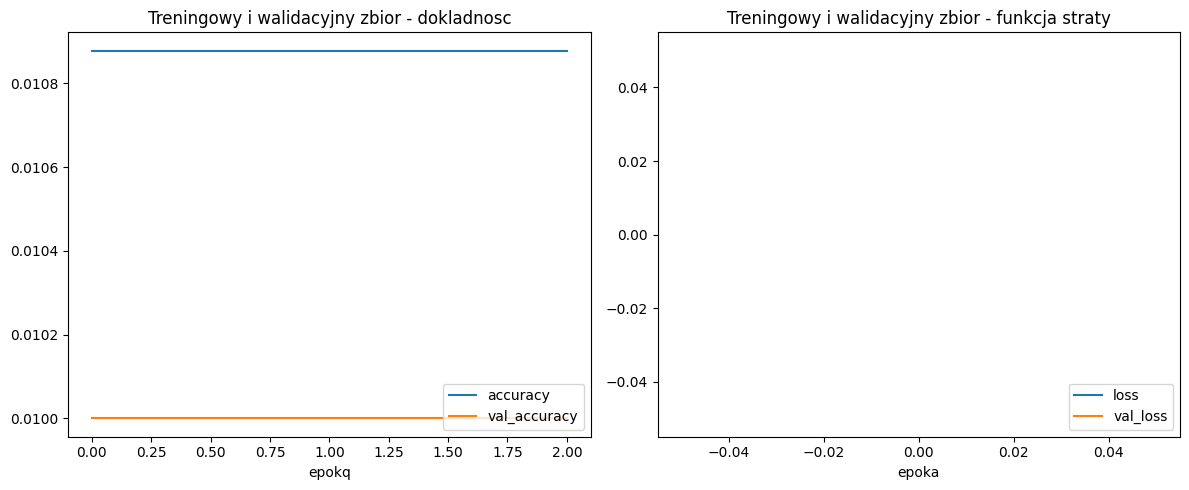

In [52]:
plotuj(fine_tune_inception1_3)

In [53]:
model.evaluate(test_set)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.0089 - loss: nan


[nan, 0.009999999776482582]